In [64]:
import numpy as np
from matplotlib import pyplot as plt
from electronic import *
from analytical import *
from integrator import *

0.050515736376957734
0.0505157299250382
0.050515713410770526
0.05051569865526987
0.05051568686201183
0.050515706765905145
0.05051573523715325
0.05051571050562359
0.05051568915077729
0.05051570598101516
0.050515708962881614
0.05051562828041542
0.050514455902676586
0.05051772373490733
0.050508511455818264
0.05052966590297758
0.05045437249295907
0.05056628261583678
0.05042624860071129
Analytical diabatic transition probability: 0.05051569515696486


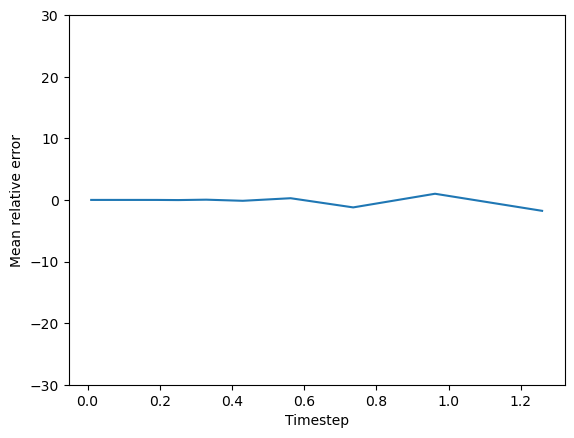

In [ ]:
# REPRODUCE PLASSER'S DATA
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))

coeff_init = np.array([1.0, 0.0], dtype=complex)
LZ_H = LandauZener(s=s, vc=c)

dt_list = np.logspace(-2, 0.1, 19)
fs_to_au = 1.0 / 0.02418884
dt_au = dt_list * fs_to_au
c_range = []

for dt in dt_au:
    c_tot = 0.0
    n_int = 5.0/(v * dt)
    t = np.arange(0, 8269, dt)
    for k in range(0,10):
        t0 = dt * (n_int + k/10)
        traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])
        q_start = traj[0]
        C_curr = LZ_H.eigvecs(q=q_start)
        coeffs = LD_propagate_CPA(model=LZ_H, dt = dt, C_curr=C_curr, coeff_init=coeff_init, q=traj)
        c_tot += np.abs(coeffs[-1][0])**2
    c_avg = 0.1 * c_tot
    print(c_avg)
    c_range.append(c_avg)

print('Analytical diabatic transition probability:', P12)

mpe = np.array(1000.0 * (c_range - P12)/P12)
plt.figure()
plt.plot(dt_list, mpe)
plt.xlabel('Timestep')
plt.ylabel('Mean relative error')
plt.ylim([-30, 30])
plt.show()

In [ ]:
# Full CPA LD benchmark
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))

LZ_H = LandauZener(s=s, vc=c)
dt = 20
n_int = 5.0/(v * dt)
t0 = dt * (n_int + 3/10)
t = np.arange(0, 8269, dt)
traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])
coeff_init = np.array([1.0, 0.0], dtype=complex)

q_start = traj[0]
C_curr = LZ_H.eigvecs(q=q_start)

coeffs = LD_propagate_CPA(model=LZ_H, dt = dt, C_curr=C_curr, coeff_init=coeff_init, q=traj)

print(np.abs(coeffs[-1][0])**2)

0.04954488191821881


In [92]:
# STEPWISE LD benchmark
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))

LZ_H = LandauZener(s=s, vc=c)
dt = 20
n_int = 5.0/(v * dt)
t0 = dt * (n_int + 3/10)
t = np.arange(0, 8269, dt)
traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])

q_start = traj[0]
C_curr = LZ_H.eigvecs(q=q_start)
coeff_curr = np.array([1.0,0.0], dtype=complex)
for step in range(len(traj)-1):
    q_curr = traj[step]
    q_next = traj[step+1] # In full dynamics replace with nuclear position propagation
    C_next, coeff_next = LD_step(LZ_H, q_curr, q_next, dt, C_curr, coeff_curr)
    C_curr = C_next
    coeff_curr = coeff_next

print(np.abs(coeff_next[0])**2)
print(coeff_next)

0.04954488191821881
[ 0.06743717-0.21212522j -0.68807263+0.69065996j]


In [102]:
# PC-REV LD result
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))

LZ_H = LandauZener(s=s, vc=c)
dt = 10.0 # here to vary the length of the timestep
n_int = 5.0/(v * dt)
t0 = dt * (n_int + 3/10)
t = np.arange(0, 8269, dt)
traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])

q_start = traj[0]
C_curr = LZ_H.eigvecs(q=q_start)
coeff_curr = np.array([1.0,0.0], dtype=complex)
for step in range(len(traj)-1):
    q_curr = traj[step]
    q_next = traj[step+1] # In full dynamics replace with nuclear position propagation
    C_next, coeff_next = LD_step(LZ_H, q_curr, q_next, dt, C_curr, coeff_curr)
    Sz_curr = sz_from_coeff(coeff_curr)
    Sz_next = sz_from_coeff(coeff_next)
    if Sz_curr * Sz_next < 0:
        tau_M, q_M, C_M, coeff_M = hop_search_bisect(LZ_H, dt, q_curr, q_next, C_curr, coeff_curr, Sz_curr, Sz_next, tol_sz=1e-12, tol_tau=1e-10)
        surface_hop_MASH(t[step]+tau_M)
        C_curr = C_M
        coeff_curr = coeff_M
        C_next, coeff_next = LD_step(LZ_H, q_M, q_next, dt-tau_M, C_curr, coeff_curr)
    C_curr = C_next
    coeff_curr = coeff_next

C_final_fwd = C_curr

print(np.abs(coeff_next[0])**2)
print(coeff_next)

0.002
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.8357175820784
0.050316915454697304
[0.03145166+0.22209842j 0.47568999+0.85053049j]


In [ ]:
# REVERSIBILITY TEST
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))
LZ_H = LandauZener(s=s, vc=c)
dt = 10.0 # here to vary the length of the timestep
n_int = 5.0/(v * dt)
t0 = dt * (n_int + 3/10)
t = np.arange(0, 8269, dt)
traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t[::-1]])
traj_forward = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])


q_start = traj[0]
C_curr = C_final_fwd
coeff_curr = np.array([0.03145166-0.22209842j, 0.47568999-0.85053049j], dtype=complex)
for step in range(len(traj)-1):
    q_curr = traj[step]
    q_next = traj[step+1] # In full dynamics replace with nuclear position propagation
    C_next, coeff_next = LD_step(LZ_H, q_curr, q_next, dt, C_curr, coeff_curr)
    Sz_curr = sz_from_coeff(coeff_curr)
    Sz_next = sz_from_coeff(coeff_next)
    if Sz_curr * Sz_next < 0:
        tau_M, q_M, C_M, coeff_M = hop_search_bisect(LZ_H, dt, q_curr, q_next, C_curr, coeff_curr, Sz_curr, Sz_next, tol_sz=1e-12, tol_tau=1e-10)
        surface_hop_MASH(t[step]+tau_M)
        C_curr = C_M
        coeff_curr = coeff_M
        C_next, coeff_next = LD_step(LZ_H, q_M, q_next, dt-tau_M, C_curr, coeff_curr)
    C_curr = C_next
    coeff_curr = coeff_next
    # print(coeff_next)

print(np.abs(coeff_next[0])**2)
print(coeff_next)

-0.002
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 5756.164282414211
0.999999996081081
[9.99999998e-01-6.43608840e-10j 8.72476256e-10+5.34041953e-10j]


In [ ]:
# CONVERGENCE STUDY -- LOG-LOG plot
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))
dt_au = np.linspace(10, 0.05, 100)

LZ_H = LandauZener(s=s, vc=c)
error_list = []
for dt in dt_au:
    # dt = 23.0 # here to vary the length of the timestep
    n_int = 5.0/(v * dt)
    t0 = dt * (n_int + 3/10)
    t = np.arange(0, 8269, dt)
    traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])

    q_start = traj[0]
    C_curr = LZ_H.eigvecs(q=q_start)
    coeff_curr = np.array([1.0,0.0], dtype=complex)
    for step in range(len(traj)-1):
        q_curr = traj[step]
        q_next = traj[step+1] # In full dynamics replace with nuclear position propagation
        C_next, coeff_next = LD_step(LZ_H, q_curr, q_next, dt, C_curr, coeff_curr)
        Sz_curr = sz_from_coeff(coeff_curr)
        Sz_next = sz_from_coeff(coeff_next)
        if Sz_curr * Sz_next < 0:
            tau_M, q_M, C_M, coeff_M = hop_search_bisect(LZ_H, dt, q_curr, q_next, C_curr, coeff_curr, Sz_curr, Sz_next, tol_sz=1e-12, tol_tau=1e-10)
            surface_hop_MASH(t[step]+tau_M)
            C_curr = C_M
            coeff_curr = coeff_M
            C_next, coeff_next = LD_step(LZ_H, q_M, q_next, dt-tau_M, C_curr, coeff_curr)
        C_curr = C_next
        coeff_curr = coeff_next
    error_list.append(np.abs(P12-np.abs(coeff_curr[0])**2))

log_time = np.log(dt_au)
log_error = np.log(np.array(error_list))
p, logC = np.polyfit(log_time, log_error, 1)
print(p)

0.002
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.8357175820784
0.002000000000000003
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.801304438308
0.0020000000000000065
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.765912465849
0.0020000000000000096
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.7309522624532
0.002000000000000013
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.7008143049525
0.0020000000000000165
Hop search finished after 35 iterations
PLACEHOLDER: A hop just happened at 2503.6787780389213
0.00200000000000002
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.652447902302
0.002000000000000024
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happened at 2503.614813771646
0.001999999999999928
Hop search finished after 36 iterations
PLACEHOLDER: A hop just happ

In [ ]:
# CONVERGENCE STUDY -- LOG-LOG plot Non rev
v = 0.002
c = 0.0033
s = 0.66
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))
dt_au = np.linspace(10, 0.05, 100)

LZ_H = LandauZener(s=s, vc=c)
error_list = []
for dt in dt_au:
    # dt = 23.0 # here to vary the length of the timestep
    n_int = 5.0/(v * dt)
    t0 = dt * (n_int + 3/10)
    t = np.arange(0, 8269, dt)
    traj = np.array([Landau_traj(v=v, t=tn, t0=t0) for tn in t])

    q_start = traj[0]
    C_curr = LZ_H.eigvecs(q=q_start)
    coeff_curr = np.array([1.0,0.0], dtype=complex)
    for step in range(len(traj)-1):
        q_curr = traj[step]
        q_next = traj[step+1] # In full dynamics replace with nuclear position propagation
        C_next, coeff_next = LD_step(LZ_H, q_curr, q_next, dt, C_curr, coeff_curr)
        C_curr = C_next
        coeff_curr = coeff_next
    error_list.append(np.abs(P12-np.abs(coeff_curr[0])**2))

log_time = np.log(dt_au)
log_error = np.log(np.array(error_list))
p, logC = np.polyfit(log_time, log_error, 1)
print(p)

2.164782299027181
